# LightGBM — model experiment

Global gradient-boosting model over all ~3,300 Store×Dept series


In [ ]:
# Environment: works both locally (repo checkout) and on Colab (Drive mount)
import importlib.util, subprocess, sys
from pathlib import Path

if importlib.util.find_spec("google.colab"):
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/ML_FINAL_PROJECT")
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data" / "train.csv.zip").exists())

for pkg in ["lightgbm", "optuna", "mlflow"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

Mounted at /content/drive
ROOT = /content/drive/MyDrive/ML_FINAL_PROJECT


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import mlflow

from src.preprocessing import Cleaner
from src.feateng import FeatureBuilder, FEATURE_GROUPS
from src.pipeline import WalmartPipeline, LogTarget, SeasonalNaive
from src.validation import FOLDS, evaluate, split_fold, wmae
from src.experiment_utils import setup_mlflow, run_stage, log_table, PyfuncPipeline

train    = pd.read_csv(ROOT / "data/train.csv.zip")
test     = pd.read_csv(ROOT / "data/test.csv.zip")
features = pd.read_csv(ROOT / "data/features.csv.zip")
stores   = pd.read_csv(ROOT / "data/stores.csv")


DAGSHUB_REPO = "ZukaCS/ML_FINAL_PROJECT"
print("tracking:", setup_mlflow(ROOT, dagshub_repo=DAGSHUB_REPO))
print("train", train.shape, "| test", test.shape)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


DagsHub username (leave blank to log locally): dgrig23
DagsHub token: ··········
tracking: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow
train (421570, 5) | test (115064, 4)


In [ ]:

_df = Cleaner(stores, features).transform(train)
_X  = FeatureBuilder(groups=["lags"]).fit(_df).transform(_df)
_s  = _df.set_index(["Store", "Dept", "Date"])["Weekly_Sales"]
_rows   = _df.sample(500, random_state=0)
_manual = _s.reindex(pd.MultiIndex.from_arrays(
    [_rows["Store"], _rows["Dept"], _rows["Date"] - pd.Timedelta(days=364)])).to_numpy()
_got = _X.loc[_rows.index, "lag_52"].to_numpy()
assert ((_manual == _got) | (np.isnan(_manual) & np.isnan(_got))).all()


_tr = train[pd.to_datetime(train["Date"]) <= pd.Timestamp(FOLDS[0]["train_end"])]
_fb = FeatureBuilder(groups=["lags"]).fit(Cleaner(stores, features).transform(_tr))
assert _fb.sales_.index.get_level_values("Date").max() <= pd.Timestamp(FOLDS[0]["train_end"])

print("sanity checks passed | lag_52 coverage on train:",
      f"{_X['lag_52'].notna().mean():.1%}")

sanity checks passed | lag_52 coverage on train: 62.0%


In [ ]:
LGB_DEFAULT = dict(
    objective="regression_l1",   # L1 = the MAE inside WMAE
    n_estimators=500, learning_rate=0.1, num_leaves=127,
    random_state=42, n_jobs=-1, verbosity=-1)

DEFAULT_GROUPS = ("lags", "lag_windows", "calendar", "holiday", "statics")

def make_pipeline(cfg, lgb_params=None):
    """cfg keys: clip_negatives, log_target, groups, drop_cols."""
    return WalmartPipeline(
        Cleaner(stores, features,
                clip_negatives=cfg.get("clip_negatives", True)),
        FeatureBuilder(groups=cfg.get("groups", DEFAULT_GROUPS),
                       drop_cols=cfg.get("drop_cols", ())),
        lgb.LGBMRegressor(**{**LGB_DEFAULT, **(lgb_params or {})}),
        target_transform=LogTarget() if cfg.get("log_target") else None,
        holiday_weight=5.0,   #  match the 5x holiday weight in WMAE
    )

## 2 · Stage: `LightGBM_Preprocessing`

A/B the cleaning knobs with a default-config model:



In [ ]:
prep_configs = {
    "clip_neg__raw":   {"clip_negatives": True,  "log_target": False},
    "keep_neg__raw":   {"clip_negatives": False, "log_target": False},
    "clip_neg__log1p": {"clip_negatives": True,  "log_target": True},
}

# fixed (not A/B'd) choices, logged on the parent run for the record
FIXED_PREP = {"markdown_impute": "zero",
              "cpi_unemp_impute": "ffill_per_store",
              "holiday_weight": 5.0}

prep_results, best_prep = run_stage(
    "LightGBM", "Preprocessing", prep_configs,
    lambda cfg: evaluate(lambda: make_pipeline(cfg), train),
    parent_log=lambda: mlflow.log_params(FIXED_PREP))

BEST_CLEAN = prep_configs[best_prep]
print("winner:", best_prep, BEST_CLEAN)
prep_results

[Preprocessing] clip_neg__raw: wmae_fold1=2,690, wmae_fold2=1,806, wmae_fold3=1,485, wmae_mean=1,994
🏃 View run clip_neg__raw at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/ae41b349aa484e7583a14687b91dc04c
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
[Preprocessing] keep_neg__raw: wmae_fold1=2,678, wmae_fold2=1,827, wmae_fold3=1,489, wmae_mean=1,998
🏃 View run keep_neg__raw at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/9a73d28fcd5549ab9b877ba16304ccc3
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
[Preprocessing] clip_neg__log1p: wmae_fold1=2,843, wmae_fold2=1,800, wmae_fold3=1,512, wmae_mean=2,051
🏃 View run clip_neg__log1p at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/953c21fcdae0422096c462a01b292f78
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
🏃 View run LightGBM_Prep

,wmae_fold1,wmae_fold2,wmae_fold3,wmae_mean
config,,,,
clip_neg__raw,2689.630817,1806.324268,1484.574631,1993.509905
keep_neg__raw,2677.800118,1826.835525,1488.607241,1997.747628
clip_neg__log1p,2842.557935,1799.659998,1512.005657,2051.407863


## 3 · Stage: `LightGBM_Feature_Engineering`



In [ ]:
#every group goes in; the selection stage decides what comes out.
ALL_GROUPS = list(FEATURE_GROUPS)

fe_results, _ = run_stage(
    "LightGBM", "Feature_Engineering",
    {"all_groups": {**BEST_CLEAN, "groups": ALL_GROUPS}},
    lambda cfg: evaluate(lambda: make_pipeline(cfg), train))

BEST_GROUPS = ALL_GROUPS
fe_results

[Feature_Engineering] all_groups: wmae_fold1=2,825, wmae_fold2=1,783, wmae_fold3=1,471, wmae_mean=2,027
🏃 View run all_groups at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/d64ac388d9a74cd099c07e6c2700398c
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
🏃 View run LightGBM_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/98147e2b3da04f909a9bb51bc894e49a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1


,wmae_fold1,wmae_fold2,wmae_fold3,wmae_mean
config,,,,
all_groups,2824.958605,1783.286318,1471.425633,2026.556852


## 4 · Stage: `LightGBM_Feature_Selection`

Selection uses the two signals gradient boosting actually gives us (both
computed from a single fold-3 fit and logged as an artifact on the parent
run)

[Feature_Selection] all_features: wmae_fold1=2,825, wmae_fold2=1,783, wmae_fold3=1,471, wmae_mean=2,027
🏃 View run all_features at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/c4a4d13482d54d4a92ecee0f47f28c85
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
[Feature_Selection] drop_low_gain: wmae_fold1=2,825, wmae_fold2=1,783, wmae_fold3=1,471, wmae_mean=2,027
🏃 View run drop_low_gain at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/feb66a23478a40c4b1dd67d0b217925a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
[Feature_Selection] drop_perm_zero: wmae_fold1=2,704, wmae_fold2=1,800, wmae_fold3=1,460, wmae_mean=1,988
🏃 View run drop_perm_zero at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/6f6a0e66d7914b6da22a8f0bbfeecf12
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
[Feature_Selecti

,wmae_fold1,wmae_fold2,wmae_fold3,wmae_mean
config,,,,
drop_union,2703.569306,1799.856932,1459.586252,1987.670830
drop_perm_zero,2703.569306,1799.856932,1459.586252,1987.670830
drop_low_gain,2824.958605,1783.286318,1471.425633,2026.556852
all_features,2824.958605,1783.286318,1471.425633,2026.556852


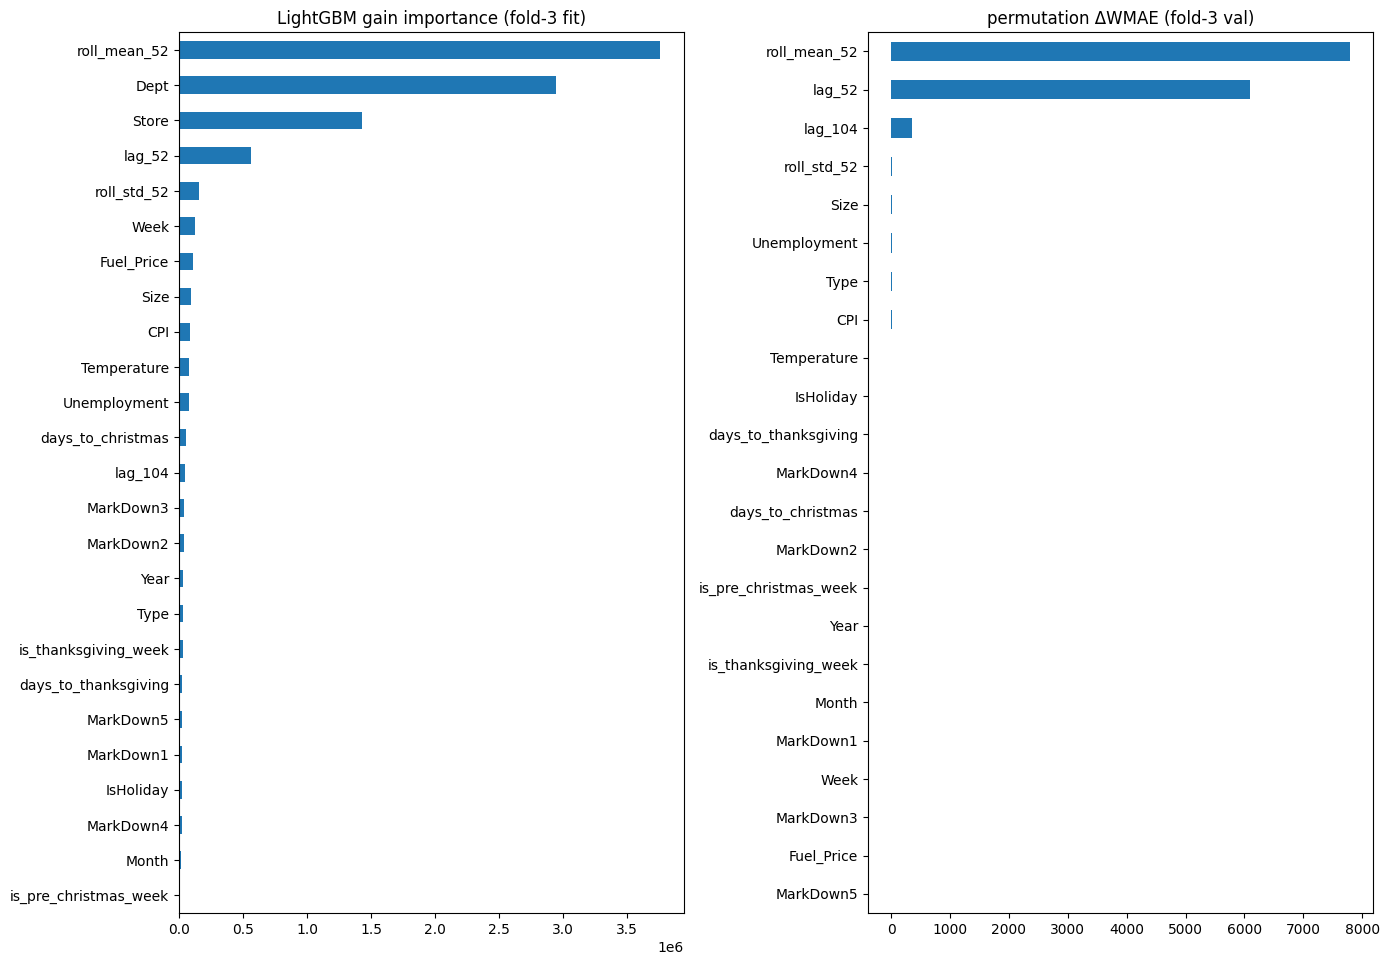

In [ ]:
import matplotlib.pyplot as plt
from src.feateng import ID_COLS


_tr, _va = split_fold(train, FOLDS[2])
_pipe = make_pipeline({**BEST_CLEAN, "groups": BEST_GROUPS}).fit(_tr)

# gain
gain = (pd.Series(_pipe.model.booster_.feature_importance("gain"),
                  index=_pipe.model.booster_.feature_name())
        .sort_values())

# perm
_X_va = _pipe.feature_builder.transform(
    _pipe.cleaner.transform(_va.drop(columns=["Weekly_Sales"])))
_y_va, _hol_va = _va["Weekly_Sales"].to_numpy(), _va["IsHoliday"].to_numpy()

def _wmae_on(X):
    p = np.asarray(_pipe.model.predict(X), dtype=float)
    if _pipe.target_transform is not None:
        p = _pipe.target_transform.inverse(p)
    return wmae(_y_va, p, _hol_va)

def _shuffled(X, col, rng):
    Xp = X.copy()

    Xp[col] = pd.Series(X[col].to_numpy()[rng.permutation(len(X))],
                        index=X.index, dtype=X[col].dtype)
    return Xp

_rng = np.random.default_rng(0)
_base = _wmae_on(_X_va)
perm = pd.Series(
    {c: np.mean([_wmae_on(_shuffled(_X_va, c, _rng)) for _ in range(3)]) - _base
     for c in _X_va.columns if c not in ID_COLS}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 0.35 * len(gain) + 1))
gain.plot.barh(ax=axes[0]); axes[0].set_title("LightGBM gain importance (fold-3 fit)")
perm.plot.barh(ax=axes[1]); axes[1].set_title("permutation ΔWMAE (fold-3 val)")
plt.tight_layout()

low_gain  = [c for c in gain.index[gain < gain.max() * 0.001] if c not in ID_COLS]
perm_zero = list(perm.index[perm <= 0])
candidates = {
    "all_features":   [],
    "drop_low_gain":  low_gain,
    "drop_perm_zero": perm_zero,
    "drop_union":     sorted(set(low_gain) | set(perm_zero)),
}
sel_configs = {name: {**BEST_CLEAN, "groups": BEST_GROUPS, "drop_cols": drops}
               for name, drops in candidates.items()}

sel_results, best_sel = run_stage(
    "LightGBM", "Feature_Selection", sel_configs,
    lambda cfg: evaluate(lambda: make_pipeline(cfg), train),
    parent_log=lambda: mlflow.log_figure(fig, "feature_importances.png"))

FINAL_DROPS = sel_configs[best_sel]["drop_cols"]
print("winner:", best_sel, "| dropped:", FINAL_DROPS or "nothing")
sel_results

## 5 · Stage: `LightGBM_CV`: hyperparameter tuning

Optuna, TPE sampler, each trial scored on all 3 folds and logged as a nested
run.

  0%|          | 0/30 [00:00<?, ?it/s]

🏃 View run trial_000 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/808e76d7cd7f498a874b9ce3273852d4
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
🏃 View run trial_001 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/fc3234804ebb4f3797a4585b073afbda
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
🏃 View run trial_002 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/1e1df09b5d074ba88bd6c0d95e27179c
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
🏃 View run trial_003 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/ed9833f1bbfc45d5bd82049dd0d5b4e1
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
🏃 View run trial_004 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/82728ef1d25848f1bd8054c3153

/tmp/ipykernel_2223/212648138.py:44: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_optimization_history(study).figure,
/tmp/ipykernel_2223/212648138.py:46: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_param_importances(study).figure,


🏃 View run LightGBM_CV at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/62900df196fe4df5aac70ea09df33850
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
best wmae_mean: 1898.3


{'n_estimators': 1130,
 'learning_rate': 0.03644596687898284,
 'num_leaves': 111,
 'min_child_samples': 43,
 'colsample_bytree': 0.8660698517703787,
 'subsample': 0.8691335636417596,
 'reg_alpha': 0.002670181929777196,
 'reg_lambda': 0.5215401717859174,
 'subsample_freq': 1}

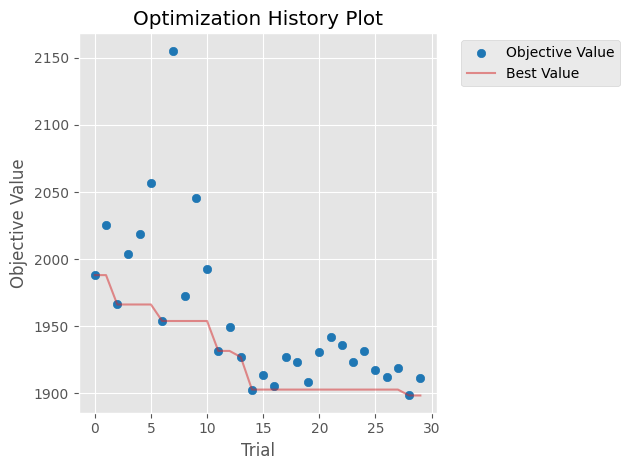

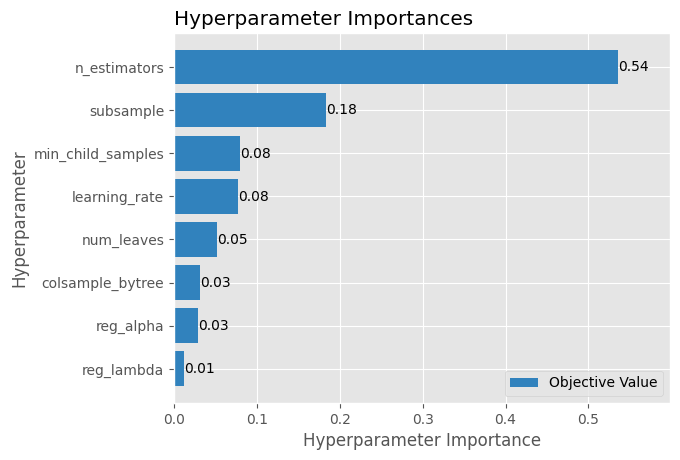

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNED_CFG = {**BEST_CLEAN, "groups": BEST_GROUPS, "drop_cols": FINAL_DROPS}
N_TRIALS = 30

mlflow.set_experiment("LightGBM_Training")
with mlflow.start_run(run_name="LightGBM_CV"):
    mlflow.set_tag("stage", "CV")
    mlflow.log_params({"n_trials": N_TRIALS,
                       **{k: str(v) for k, v in TUNED_CFG.items()}})

    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 300, 1200),
            learning_rate     = trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
            num_leaves        = trial.suggest_int("num_leaves", 31, 255, log=True),
            min_child_samples = trial.suggest_int("min_child_samples", 10, 100, log=True),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
            subsample         = trial.suggest_float("subsample", 0.6, 1.0),
            subsample_freq    = 1,
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        )
        with mlflow.start_run(run_name=f"trial_{trial.number:03d}", nested=True):
            mlflow.log_params(params)
            metrics = evaluate(lambda: make_pipeline(TUNED_CFG, params), train,
                               train_metrics=True)
            mlflow.log_metrics(metrics)
        return metrics["wmae_mean"]

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    BEST_PARAMS = dict(study.best_params, subsample_freq=1)
    mlflow.log_metric("best_wmae_mean", study.best_value)
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})


    try:
        from optuna.visualization.matplotlib import (
            plot_optimization_history, plot_param_importances)
        mlflow.log_figure(plot_optimization_history(study).figure,
                          "cv_optimization_history.png")
        mlflow.log_figure(plot_param_importances(study).figure,
                          "cv_param_importances.png")
    except Exception as e:
        print("optuna plots skipped:", e)

print("best wmae_mean:", round(study.best_value, 1))
BEST_PARAMS

## 6 · Stage: `LightGBM_Final`

Retrain the winning config on **all** training data, log the whole
Cleaner→FeatureBuilder→model pipeline as an MLflow pyfunc model. + create submission file

In [ ]:
mlflow.set_experiment("LightGBM_Training")
with mlflow.start_run(run_name="LightGBM_Final") as final_run:
    mlflow.set_tag("stage", "Final")

    final_pipe = make_pipeline(TUNED_CFG, BEST_PARAMS).fit(train)
    final_metrics = evaluate(lambda: make_pipeline(TUNED_CFG, BEST_PARAMS), train,
                             train_metrics=True)
    mlflow.log_params({**{k: str(v) for k, v in final_pipe.get_params().items()},
                       **{f"lgb_{k}": v for k, v in BEST_PARAMS.items()}})
    mlflow.log_metrics(final_metrics)


    preds = final_pipe.predict(test)
    assert len(preds) == len(test) and not np.isnan(preds).any()

    mlflow.pyfunc.log_model(
        name="model",
        python_model=PyfuncPipeline(final_pipe),
        code_paths=[str(ROOT / "src")],
        input_example=test.head(5),
    )

    sub = pd.DataFrame({
        "Id": test["Store"].astype(str) + "_" + test["Dept"].astype(str)
              + "_" + test["Date"].astype(str),
        "Weekly_Sales": preds,
    })
    (ROOT / "submissions").mkdir(exist_ok=True)
    sub_path = ROOT / "submissions" / "submission_lightgbm.csv"
    sub.to_csv(sub_path, index=False)
    mlflow.log_artifact(str(sub_path))

# after submitting submission_lightgbm.csv, record the leaderboard score here:
# mlflow.log_metric("kaggle_wmae", <score>, run_id=final_run.info.run_id)
print("final CV:", {k: round(v, 1) for k, v in final_metrics.items()})
print("run_id:", final_run.info.run_id)
sub.head()

2026/07/08 22:52:17 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/08 22:52:17 INFO mlflow.pyfunc: Inferring model signature from input example
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64)

🏃 View run LightGBM_Final at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1/runs/81daa2cfa29647db9aa02ef7a534bd35
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/1
final CV: {'wmae_fold1': 2563.1, 'train_wmae_fold1': 1542.5, 'gap_fold1': 1020.5, 'wmae_fold2': 1732.1, 'train_wmae_fold2': 1614.4, 'gap_fold2': 117.8, 'wmae_fold3': 1399.6, 'train_wmae_fold3': 1554.2, 'gap_fold3': -154.6, 'wmae_mean': 1898.3, 'train_wmae_mean': 1570.4, 'gap_mean': 327.9}
run_id: 81daa2cfa29647db9aa02ef7a534bd35


,Id,Weekly_Sales
0,1_1_2012-11-02,33497.630821
1,1_1_2012-11-09,21498.665364
2,1_1_2012-11-16,20838.466046
3,1_1_2012-11-23,21150.694249
4,1_1_2012-11-30,26631.175816
